In [ ]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


ROOT_DIR = Path(
    "/shared/data_zfs/blue2959/ND_Aligner/"
    + "experiments/v2.2/conv1d_rf_sweep/confirm"
)

EXPECTED_SEEDS = {1234, 1235, 1236}

DIR_PATTERN = re.compile(
    r"^conv_RF=(?P<conv_rf>l2|\d+)_"
    + r"dec_RF=(?P<dec_rf>\d+)_"
    + r"seed=(?P<seed>\d+)$",
    flags=re.IGNORECASE,
)

In [ ]:
records = []

for exp_dir in sorted(ROOT_DIR.iterdir()):
    if not exp_dir.is_dir():
        continue

    match = DIR_PATTERN.fullmatch(exp_dir.name)
    if match is None:
        continue

    metric_path = exp_dir / "eval_metrics.csv"

    if not metric_path.exists():
        print(f"[경고] eval_metrics.csv 없음: {exp_dir.name}")
        continue

    metric_df = pd.read_csv(metric_path)

    required_columns = {
        "word_boundary_error",
        "p_word_25ms",
    }
    missing_columns = required_columns - set(metric_df.columns)

    if missing_columns:
        raise ValueError(
            f"{metric_path}에 필요한 열이 없습니다: "
            + f"{sorted(missing_columns)}"
        )

    if metric_df.empty:
        print(f"[경고] 비어 있는 CSV: {metric_path}")
        continue

    if len(metric_df) > 1:
        print(
            f"[경고] {exp_dir.name}: row가 {len(metric_df)}개이므로 "
            + "마지막 row를 사용합니다."
        )

    row = metric_df.iloc[-1]

    records.append(
        {
            # 숫자 RF와 l2를 함께 다루기 위해 문자열로 저장
            "conv_rf": match.group("conv_rf").lower(),
            "dec_rf": int(match.group("dec_rf")),
            "seed": int(match.group("seed")),
            "wbe_ms": float(row["word_boundary_error"]) * 1000.0,
            "p25": float(row["p_word_25ms"]),
        }
    )


result_df = pd.DataFrame(records)

if result_df.empty:
    raise RuntimeError(f"실험 결과를 찾지 못했습니다: {ROOT_DIR}")

result_df = result_df[
    result_df["seed"].isin(EXPECTED_SEEDS)
].copy()


# x축 순서: L2 baseline 이후 숫자 Conv RF
numeric_conv_rfs = sorted(
    int(value)
    for value in result_df["conv_rf"].unique()
    if value != "l2"
)

conv_rf_order = []

if "l2" in result_df["conv_rf"].unique():
    conv_rf_order.append("l2")

conv_rf_order.extend(
    str(value) for value in numeric_conv_rfs
)

result_df["conv_rf"] = pd.Categorical(
    result_df["conv_rf"],
    categories=conv_rf_order,
    ordered=True,
)

result_df = (
    result_df
    .sort_values(["conv_rf", "dec_rf", "seed"])
    .reset_index(drop=True)
)

display(result_df)

print(f"불러온 결과 수: {len(result_df)}")
print(f"Scorer 순서: {conv_rf_order}")
print(f"Decoder RF: {sorted(result_df['dec_rf'].unique())}")

,conv_rf,dec_rf,seed,wbe_ms,p25
0,l2,1,1234,31.528078,66.702151
1,l2,1,1235,33.994913,65.844572
2,l2,1,1236,31.937022,66.489238
3,l2,5,1234,28.285168,71.102434
4,l2,5,1235,28.722364,71.498698
...,...,...,...,...,...
69,13,13,1235,25.250215,66.057485
70,13,13,1236,25.938189,64.868701
71,13,17,1234,27.019236,62.361014
72,13,17,1235,28.158436,60.184526


불러온 결과 수: 74
Scorer 순서: ['l2', '1', '5', '9', '13']
Decoder RF: [np.int64(1), np.int64(5), np.int64(9), np.int64(13), np.int64(17)]


In [17]:
duplicate_mask = result_df.duplicated(
    subset=["conv_rf", "dec_rf", "seed"],
    keep=False,
)

if duplicate_mask.any():
    print("[오류] 중복된 RF/seed 조합이 있습니다.")

    display(
        result_df.loc[duplicate_mask].sort_values(
            ["conv_rf", "dec_rf", "seed"]
        )
    )

    raise ValueError("중복된 실험 결과를 먼저 확인해주세요.")

print("중복된 실험 결과 없음")

중복된 실험 결과 없음


In [18]:
seed_check_df = (
    result_df
    .groupby(
        ["conv_rf", "dec_rf"],
        observed=True,
    )["seed"]
    .agg(lambda values: set(values))
    .reset_index(name="observed_seeds")
)

seed_check_df["missing_seeds"] = (
    seed_check_df["observed_seeds"].apply(
        lambda seeds: EXPECTED_SEEDS - seeds
    )
)

seed_check_df["complete"] = (
    seed_check_df["observed_seeds"].apply(
        lambda seeds: seeds == EXPECTED_SEEDS
    )
)

incomplete_df = seed_check_df.loc[
    ~seed_check_df["complete"]
]

if incomplete_df.empty:
    print("모든 실험 조합에 세 seed가 존재합니다.")
else:
    print("[경고] seed가 모두 존재하지 않는 조합:")
    display(incomplete_df)

[경고] seed가 모두 존재하지 않는 조합:


,conv_rf,dec_rf,observed_seeds,missing_seeds,complete
4,l2,17,"{1234, 1235}",{1236},False


In [19]:
seed_check_df = (
    result_df
    .groupby(
        ["conv_rf", "dec_rf"],
        observed=True,
    )["seed"]
    .agg(lambda values: set(values))
    .reset_index(name="observed_seeds")
)

seed_check_df["missing_seeds"] = (
    seed_check_df["observed_seeds"].apply(
        lambda seeds: EXPECTED_SEEDS - seeds
    )
)

seed_check_df["complete"] = (
    seed_check_df["observed_seeds"].apply(
        lambda seeds: seeds == EXPECTED_SEEDS
    )
)

incomplete_df = seed_check_df.loc[
    ~seed_check_df["complete"]
]

if incomplete_df.empty:
    print("모든 실험 조합에 세 seed가 존재합니다.")
else:
    print("[경고] seed가 모두 존재하지 않는 조합:")
    display(incomplete_df)

[경고] seed가 모두 존재하지 않는 조합:


,conv_rf,dec_rf,observed_seeds,missing_seeds,complete
4,l2,17,"{1234, 1235}",{1236},False


In [20]:
complete_configs = seed_check_df.loc[
    seed_check_df["complete"],
    ["conv_rf", "dec_rf"],
]

complete_result_df = result_df.merge(
    complete_configs,
    on=["conv_rf", "dec_rf"],
    how="inner",
)

summary_df = (
    complete_result_df
    .groupby(
        ["conv_rf", "dec_rf"],
        observed=True,
        as_index=False,
    )
    .agg(
        seed_count=("seed", "nunique"),
        wbe_mean=("wbe_ms", "mean"),
        wbe_std=("wbe_ms", "std"),
        p25_mean=("p25", "mean"),
        p25_std=("p25", "std"),
    )
    .sort_values(["dec_rf", "conv_rf"])
    .reset_index(drop=True)
)

display(
    summary_df.round(
        {
            "wbe_mean": 3,
            "wbe_std": 3,
            "p25_mean": 3,
            "p25_std": 3,
        }
    )
)

,conv_rf,dec_rf,seed_count,wbe_mean,wbe_std,p25_mean,p25_std
0,l2,1,3,32.487,1.322,66.345,0.447
1,1,1,3,26.389,0.145,67.964,0.501
2,5,1,3,23.149,0.510,68.187,0.815
3,9,1,3,22.015,0.262,71.057,0.487
4,13,1,3,21.919,0.186,70.809,0.404
5,l2,5,3,27.517,1.723,71.678,0.683
6,1,5,3,24.727,0.527,71.859,0.354
7,5,5,3,21.698,0.377,71.680,0.389
8,9,5,3,22.081,0.041,70.842,0.541
9,13,5,3,21.821,0.188,70.748,0.275


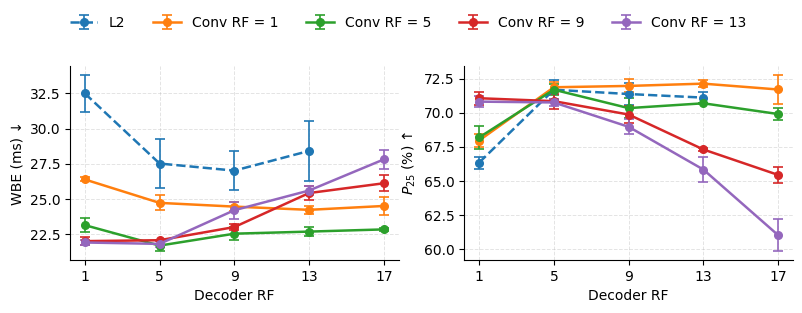

PDF 저장 완료: /shared/data_zfs/blue2959/ND_Aligner/experiments/v2.2/conv1d_rf_sweep/confirm/conv1d_rf_sweep_dec_rf_xaxis.pdf
PNG 저장 완료: /shared/data_zfs/blue2959/ND_Aligner/experiments/v2.2/conv1d_rf_sweep/confirm/conv1d_rf_sweep_dec_rf_xaxis.png


In [22]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(8.0, 3.0),
    sharex=True,
)

metric_specs = [
    {
        "ax": axes[0],
        "mean": "wbe_mean",
        "std": "wbe_std",
        "ylabel": "WBE (ms) ↓",
    },
    {
        "ax": axes[1],
        "mean": "p25_mean",
        "std": "p25_std",
        "title": r"$P_{25}$",
        "ylabel": r"$P_{25}$ (%) ↑",
    },
]


# L2를 먼저 표시한 뒤 숫자 Conv RF를 오름차순으로 표시
observed_conv_rfs = set(
    summary_df["conv_rf"].astype(str)
)

plot_conv_order = [
    conv_rf
    for conv_rf in conv_rf_order
    if conv_rf in observed_conv_rfs
]

dec_rfs = sorted(
    summary_df["dec_rf"].unique()
)

color_map = plt.get_cmap("tab10")


# 하나의 선이 하나의 scorer 설정을 나타냄
for line_idx, conv_rf in enumerate(plot_conv_order):
    conv_result = (
        summary_df[
            summary_df["conv_rf"].astype(str) == conv_rf
        ]
        .sort_values("dec_rf")
    )

    color = color_map(line_idx % 10)

    if conv_rf == "l2":
        line_label = "L2"
        line_style = "--"
    else:
        line_label = f"Conv RF = {conv_rf}"
        line_style = "-"

    for spec in metric_specs:
        spec["ax"].errorbar(
            x=conv_result["dec_rf"],
            y=conv_result[spec["mean"]],
            yerr=conv_result[spec["std"]],
            label=line_label,
            color=color,
            linestyle=line_style,
            marker="o",
            markersize=5.5,
            linewidth=1.8,
            elinewidth=1.2,
            capsize=3.5,
            capthick=1.2,
            zorder=3,
        )


for spec in metric_specs:
    ax = spec["ax"]

    # ax.set_title(
    #     spec["title"],
    #     fontsize=12,
    # )
    ax.set_xlabel(
        "Decoder RF"
    )
    ax.set_ylabel(
        spec["ylabel"]
    )

    ax.set_xticks(dec_rfs)

    ax.grid(
        True,
        linestyle="--",
        linewidth=0.7,
        alpha=0.35,
        zorder=0,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.05),
    ncol=min(len(plot_conv_order), 5),
    frameon=False,
)

fig.tight_layout(
    rect=(0, 0, 1, 0.89)
)


output_pdf = (
    ROOT_DIR
    / "conv1d_rf_sweep_dec_rf_xaxis.pdf"
)

output_png = (
    ROOT_DIR
    / "conv1d_rf_sweep_dec_rf_xaxis.png"
)

fig.savefig(
    output_pdf,
    bbox_inches="tight",
)

fig.savefig(
    output_png,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"PDF 저장 완료: {output_pdf}")
print(f"PNG 저장 완료: {output_png}")